In [4]:
# 1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [15]:
# 2. Загрузка датасета
#Iris Dataset 
data = load_iris()


X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Размер датасета: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Классы: {data.target_names}")
print(f"\nПервые строки данных:")
print(X.head())


Размер датасета: (150, 4)
Количество классов: 3
Классы: ['setosa' 'versicolor' 'virginica']

Первые строки данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


=== СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
target
0    50
1    50
2    50
Name: count, dtype: int64


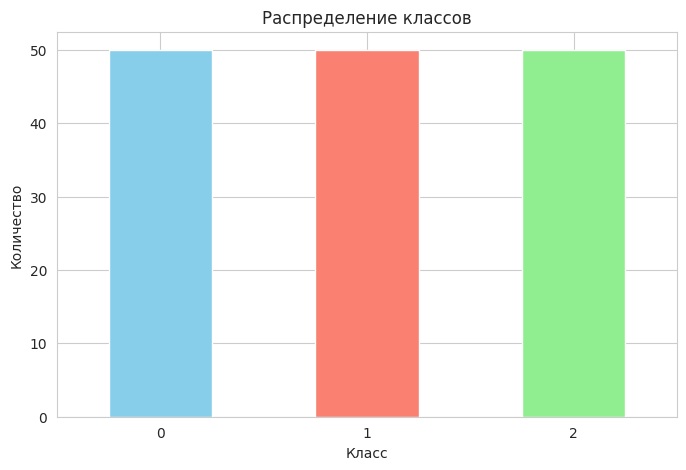

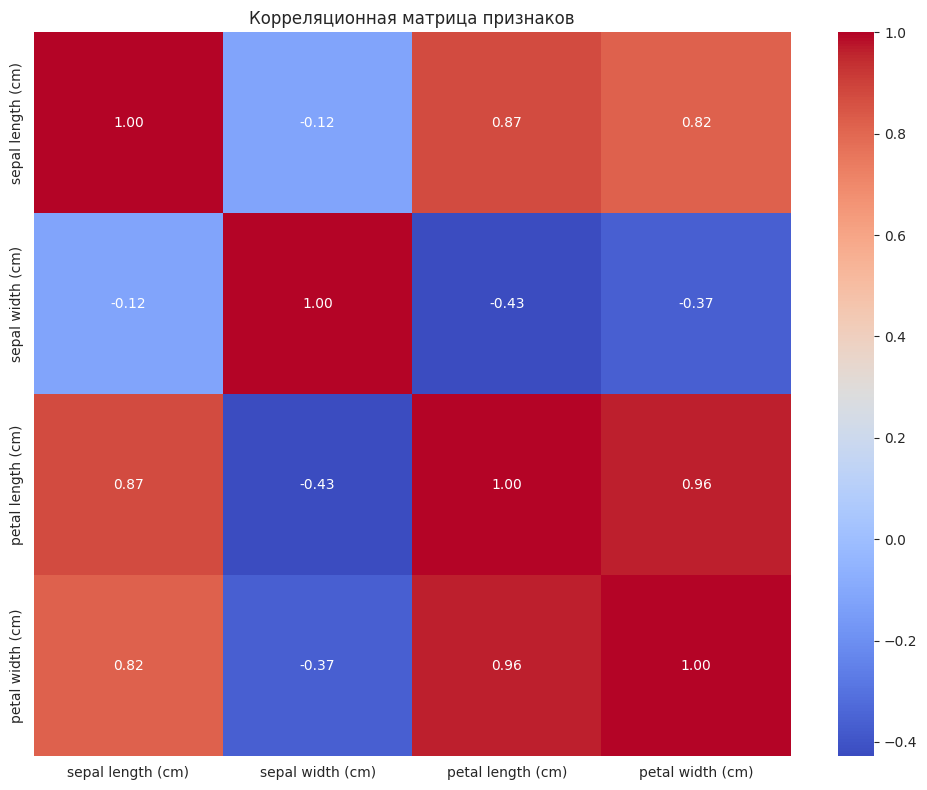

In [6]:
# 3. Разведочный анализ данных (EDA)
print("=== СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
print(y.value_counts())

# Визуализация распределения классов
plt.figure(figsize=(8, 5))
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

# Корреляционная матрица признаков
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

In [7]:
# 4. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts()}")
print(f"\nРаспределение классов в тестовой выборке:\n{y_test.value_counts()}")

Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)

Распределение классов в обучающей выборке:
target
1    35
0    35
2    35
Name: count, dtype: int64

Распределение классов в тестовой выборке:
target
2    15
1    15
0    15
Name: count, dtype: int64


In [ ]:
# 5. Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено")
print(f"Среднее до масштабирования: {X_train.iloc[:, 0].mean():.2f}")
print(f"Среднее после масштабирования: {X_train_scaled[:, 0].mean():.4f}")

Масштабирование выполнено
Среднее до масштабирования: 5.87
Среднее после масштабирования: 0.0000


=== БАЗОВАЯ МОДЕЛЬ KNN (K=5) ===
Accuracy: 0.9111
Precision: 0.9298
Recall: 0.9111
F1-Score: 0.9095

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



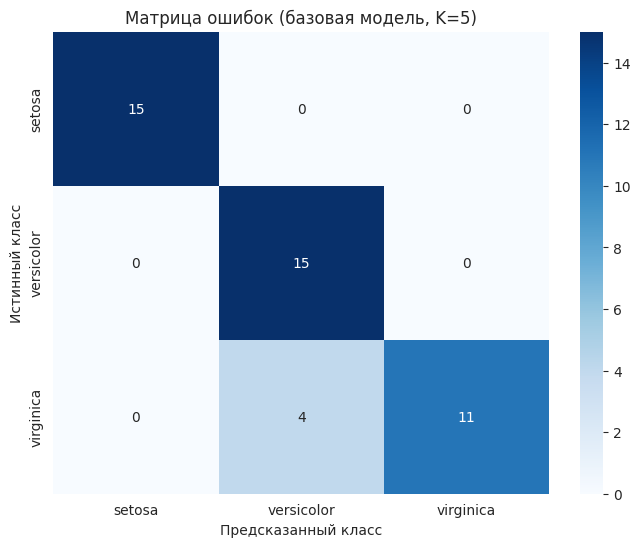

In [9]:
# 6. Обучение базовой модели KNN с произвольным K
print("=== БАЗОВАЯ МОДЕЛЬ KNN (K=5) ===")

# Создаем и обучаем модель
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)

# Предсказания
y_pred_base = knn_base.predict(X_test_scaled)

# Метрики качества
accuracy_base = accuracy_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base, average='weighted')
recall_base = recall_score(y_test, y_pred_base, average='weighted')
f1_base = f1_score(y_test, y_pred_base, average='weighted')

print(f"Accuracy: {accuracy_base:.4f}")
print(f"Precision: {precision_base:.4f}")
print(f"Recall: {recall_base:.4f}")
print(f"F1-Score: {f1_base:.4f}")

# Детальный отчет
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_base, target_names=data.target_names))

# Матрица ошибок
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Матрица ошибок (базовая модель, K=5)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

In [10]:
# 7. Подбор гиперпараметра K с использованием GridSearchCV

print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ: GridSearchCV ===")

# Определяем сетку параметров
param_grid = {
    'n_neighbors': list(range(1, 31)),  # K от 1 до 30
    'weights': ['uniform', 'distance'],  # Способ взвешивания соседей
    'metric': ['euclidean', 'manhattan']  # Метрика расстояния
}

# Стратегия 1: StratifiedKFold (5 фолдов)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=stratified_kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучение
grid_search.fit(X_train_scaled, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на кросс-валидации: {grid_search.best_score_:.4f}")

# Лучшая модель
best_knn_grid = grid_search.best_estimator_

=== ПОДБОР ГИПЕРПАРАМЕТРОВ: GridSearchCV ===
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'}
Лучший score на кросс-валидации: 0.9714


In [11]:
# 8. Подбор гиперпараметра K с использованием RandomizedSearchCV

print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ: RandomizedSearchCV ===")

# Определяем распределение параметров
param_dist = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2, 3]  # Параметр для метрики Minkowski
}

# Стратегия 2: KFold (10 фолдов)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=100,  # Количество случайных комбинаций
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Обучение
random_search.fit(X_train_scaled, y_train)

print(f"\nЛучшие параметры: {random_search.best_params_}")
print(f"Лучший score на кросс-валидации: {random_search.best_score_:.4f}")

# Лучшая модель
best_knn_random = random_search.best_estimator_

=== ПОДБОР ГИПЕРПАРАМЕТРОВ: RandomizedSearchCV ===
Fitting 10 folds for each of 100 candidates, totalling 1000 fits

Лучшие параметры: {'weights': 'distance', 'p': 3, 'n_neighbors': 22, 'metric': 'euclidean'}
Лучший score на кросс-валидации: 0.9818


In [12]:
# 9. Оценка оптимальных моделей на тестовой выборке

print("=== ОЦЕНКА ОПТИМАЛЬНОЙ МОДЕЛИ (GridSearchCV) ===")
y_pred_grid = best_knn_grid.predict(X_test_scaled)

accuracy_grid = accuracy_score(y_test, y_pred_grid)
precision_grid = precision_score(y_test, y_pred_grid, average='weighted')
recall_grid = recall_score(y_test, y_pred_grid, average='weighted')
f1_grid = f1_score(y_test, y_pred_grid, average='weighted')

print(f"Accuracy: {accuracy_grid:.4f}")
print(f"Precision: {precision_grid:.4f}")
print(f"Recall: {recall_grid:.4f}")
print(f"F1-Score: {f1_grid:.4f}")

print("\n=== ОЦЕНКА ОПТИМАЛЬНОЙ МОДЕЛИ (RandomizedSearchCV) ===")
y_pred_random = best_knn_random.predict(X_test_scaled)

accuracy_random = accuracy_score(y_test, y_pred_random)
precision_random = precision_score(y_test, y_pred_random, average='weighted')
recall_random = recall_score(y_test, y_pred_random, average='weighted')
f1_random = f1_score(y_test, y_pred_random, average='weighted')

print(f"Accuracy: {accuracy_random:.4f}")
print(f"Precision: {precision_random:.4f}")
print(f"Recall: {recall_random:.4f}")
print(f"F1-Score: {f1_random:.4f}")

=== ОЦЕНКА ОПТИМАЛЬНОЙ МОДЕЛИ (GridSearchCV) ===
Accuracy: 0.9111
Precision: 0.9298
Recall: 0.9111
F1-Score: 0.9095

=== ОЦЕНКА ОПТИМАЛЬНОЙ МОДЕЛИ (RandomizedSearchCV) ===
Accuracy: 0.9111
Precision: 0.9155
Recall: 0.9111
F1-Score: 0.9107


=== СРАВНЕНИЕ МОДЕЛЕЙ ===
            Модель  Accuracy  Precision   Recall  F1-Score
     Базовая (K=5)  0.911111   0.929825 0.911111  0.909502
      GridSearchCV  0.911111   0.929825 0.911111  0.909502
RandomizedSearchCV  0.911111   0.915535 0.911111  0.910714


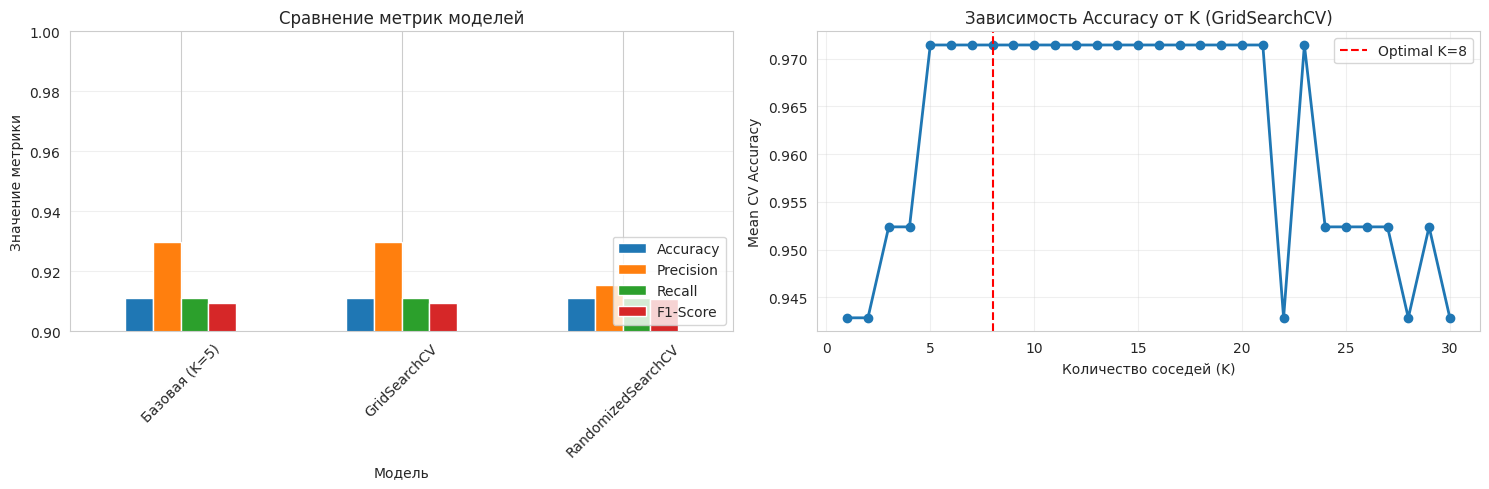

In [13]:
# 10. Сравнение всех моделей

print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")

comparison_df = pd.DataFrame({
    'Модель': ['Базовая (K=5)', 'GridSearchCV', 'RandomizedSearchCV'],
    'Accuracy': [accuracy_base, accuracy_grid, accuracy_random],
    'Precision': [precision_base, precision_grid, precision_random],
    'Recall': [recall_base, recall_grid, recall_random],
    'F1-Score': [f1_base, f1_grid, f1_random]
})

print(comparison_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Сравнение метрик
comparison_df.set_index('Модель')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], rot=45
)
axes[0].set_title('Сравнение метрик моделей')
axes[0].set_ylabel('Значение метрики')
axes[0].set_ylim([0.9, 1.0])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# График 2: Зависимость accuracy от K (по результатам GridSearch)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_grouped = cv_results.groupby('param_n_neighbors')['mean_test_score'].max()

axes[1].plot(cv_results_grouped.index, cv_results_grouped.values, 
             marker='o', linewidth=2, markersize=6)
axes[1].set_title('Зависимость Accuracy от K (GridSearchCV)')
axes[1].set_xlabel('Количество соседей (K)')
axes[1].set_ylabel('Mean CV Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=grid_search.best_params_['n_neighbors'], 
                color='r', linestyle='--', label=f"Optimal K={grid_search.best_params_['n_neighbors']}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# 11. Итоговые выводы

print("\n=== ИТОГОВЫЕ ВЫВОДЫ ===")
print(f"\n1. Базовая модель (K=5):")
print(f"   - Accuracy: {accuracy_base:.4f}")

print(f"\n2. Оптимизация через GridSearchCV:")
print(f"   - Лучшие параметры: {grid_search.best_params_}")
print(f"   - Accuracy: {accuracy_grid:.4f}")
print(f"   - Улучшение: {(accuracy_grid - accuracy_base):.4f} ({((accuracy_grid - accuracy_base)/accuracy_base * 100):.2f}%)")

print(f"\n3. Оптимизация через RandomizedSearchCV:")
print(f"   - Лучшие параметры: {random_search.best_params_}")
print(f"   - Accuracy: {accuracy_random:.4f}")
print(f"   - Улучшение: {(accuracy_random - accuracy_base):.4f} ({((accuracy_random - accuracy_base)/accuracy_base * 100):.2f}%)")

print(f"\n4. Стратегии кросс-валидации:")
print(f"   - GridSearchCV: StratifiedKFold (5 фолдов)")
print(f"   - RandomizedSearchCV: KFold (10 фолдов)")

# Сохранение результатов
comparison_df.to_csv('knn_model_comparison.csv', index=False)
print("\nРезультаты сохранены в 'knn_model_comparison.csv'")


=== ИТОГОВЫЕ ВЫВОДЫ ===

1. Базовая модель (K=5):
   - Accuracy: 0.9111

2. Оптимизация через GridSearchCV:
   - Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'}
   - Accuracy: 0.9111
   - Улучшение: 0.0000 (0.00%)

3. Оптимизация через RandomizedSearchCV:
   - Лучшие параметры: {'weights': 'distance', 'p': 3, 'n_neighbors': 22, 'metric': 'euclidean'}
   - Accuracy: 0.9111
   - Улучшение: 0.0000 (0.00%)

4. Стратегии кросс-валидации:
   - GridSearchCV: StratifiedKFold (5 фолдов)
   - RandomizedSearchCV: KFold (10 фолдов)

Результаты сохранены в 'knn_model_comparison.csv'
